In [1]:
#relevant libraries
import numpy as np
import urllib.request
import os
import matplotlib.pyplot as plt
import sklearn.linear_model as sk

In [2]:
#preprocessing
url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
file_path = "mnist.npz"

if not os.path.exists(file_path):
    urllib.request.urlretrieve(url, file_path)

with np.load(file_path) as data:
    x_train, y_train = data['x_train'], data['y_train']
    x_test, y_test = data['x_test'], data['y_test']

train_mask_4 = np.isin(y_train, [4])
train_mask_9 = np.isin(y_train, [9])
test_mask_4 = np.isin(y_test, [4])
test_mask_9 = np.isin(y_test, [9])

x_train_filtered_4 = x_train[train_mask_4]
x_train_filtered_9 = x_train[train_mask_9]
x_test_filtered_4 = x_test[test_mask_4]
x_test_filtered_9 = x_test[test_mask_9]

x_train_flat_4 = x_train_filtered_4.reshape(x_train_filtered_4.shape[0], -1)
x_test_flat_4 = x_test_filtered_4.reshape(x_test_filtered_4.shape[0], -1)
x_train_flat_9 = x_train_filtered_9.reshape(x_train_filtered_9.shape[0], -1)
x_test_flat_9 = x_test_filtered_9.reshape(x_test_filtered_9.shape[0], -1)

x_train_processed_4 = x_train_flat_4.astype(np.float32) / 255.0
x_test_processed_4 = x_test_flat_4.astype(np.float32) / 255.0
x_train_processed_9 = x_train_flat_9.astype(np.float32) / 255.0
x_test_processed_9 = x_test_flat_9.astype(np.float32) / 255.0

x_val_4 = x_train_processed_4[:1000]
x_val_9 = x_train_processed_9[:1000]

x_train_4_final = x_train_processed_4[1000:]
x_train_9_final = x_train_processed_9[1000:]

x_train = np.vstack((x_train_4_final, x_train_9_final))
x_val = np.vstack((x_val_4, x_val_9))
x_test = np.vstack((x_test_processed_4, x_test_processed_9))

y_train = np.concatenate((-np.ones(len(x_train_4_final)), np.ones(len(x_train_9_final))))
y_val = np.concatenate((-np.ones(len(x_val_4)), np.ones(len(x_val_9))))
y_test = np.concatenate((-np.ones(len(x_test_processed_4)), np.ones(len(x_test_processed_9))))

In [3]:
def compute_mean(data_matrix):
    return np.mean(data_matrix, axis=0)

def compute_covariance(data_matrix):
    N = data_matrix.shape[0]
    return (data_matrix.T @ data_matrix) / (N - 1)
    
def pca(samples, variance=1.0, components=0):
    print(f"Training set shape ({samples.shape[0]},{samples.shape[1]})")
    
    #mean and center data
    mean = compute_mean(samples)
    print(f"Mean shape {mean.shape}")
    centered_data_mat = samples - mean
    print(f"Centered data matrix shape {centered_data_mat.shape}")
    
    #covariance matrix
    covariance = compute_covariance(centered_data_mat)
    print(f"Cov matrix shape {covariance.shape}")
    
    
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    eigenvalues = np.maximum(eigenvalues, 0)
            
    #eigenvalues and eigenvectors in descending order
    sorted_indices = np.argsort(eigenvalues)[::-1]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]
    sorted_eigenvalues = eigenvalues[sorted_indices]

    #variance preservation
    if 0 < variance < 1:
        explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
        cumulative_variance = np.cumsum(explained_variance_ratio)
        
        retain_indices = np.argmax(cumulative_variance >= variance) + 1
        return sorted_eigenvectors[:, :retain_indices]

    #pca components
    elif 0 < components < sorted_eigenvectors.shape[1]:
        return sorted_eigenvectors[:, :components]

    return sorted_eigenvectors

def apply_pca(samples, w, mean):
    samples = samples - mean
    return samples @ w

In [7]:
#apply pca on train set to reduce dim to 5
x_train_mean = np.mean(x_train, axis=0)
w = pca(x_train, components=5)
x_train_reduced = apply_pca(x_train,w,x_train_mean)
x_test_reduced = apply_pca(x_test,w,x_train_mean)
x_val_reduced = apply_pca(x_val,w,x_train_mean)

Training set shape (9791,784)
Mean shape (784,)
Centered data matrix shape (9791, 784)
Cov matrix shape (784, 784)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def alpha(err):
    # Added a tiny epsilon to prevent division by zero in perfectly pure splits
    epsilon = 1e-10
    err = np.clip(err, epsilon, 1 - epsilon)
    return 0.5 * np.log((1 - err) / err)

def predict(stump, X):
    # Highly optimized vectorized prediction using np.where
    return np.where(X[:, stump['feature']] <= stump['threshold'], stump['left'], stump['right'])

def decision_stump(x_train, y_train, weights):
    stump = {}
    best_err = float('inf')
    n_samples, n_features = x_train.shape
    
    for feature in range(n_features):
        x_col = x_train[:, feature]
        sorted_vals = np.sort(np.unique(x_col))
        midpoints = (sorted_vals[:-1] + sorted_vals[1:]) / 2
        
        if len(midpoints) > 1000:
            random_midpoints = np.random.choice(midpoints, size=1000, replace=False)
        else:
            random_midpoints = midpoints

        for pt in random_midpoints:
            left_mask = x_col <= pt
            
            # FAST POLARITY CHECK: 
            # Instead of finding the mode (slow), test the two possible stump configurations
            
            # Configuration 1: Left is -1, Right is 1
            pred_1 = np.where(left_mask, -1, 1)
            err_1 = np.sum(weights[pred_1 != y_train])
            
            # Configuration 2: Left is 1, Right is -1
            pred_2 = np.where(left_mask, 1, -1)
            err_2 = np.sum(weights[pred_2 != y_train])
            
            # Check which configuration is better
            if err_1 < best_err:
                best_err = err_1
                stump = {'feature': feature, 'threshold': pt, 'left': -1, 'right': 1}
                
            if err_2 < best_err:
                best_err = err_2
                stump = {'feature': feature, 'threshold': pt, 'left': 1, 'right': -1}

    return stump, best_err 

def update_weights(weights, labels, pred, a):
    indices = labels != pred
    weights[indices] *= np.exp(2 * a)
    # AdaBoost requires weights to be normalized so they sum to 1
    weights /= np.sum(weights) 
    return weights

def predict_ensemble(ensemble, alphas, X, num_trees):
    running_pred = np.zeros(X.shape[0])
    for t in range(num_trees):
        running_pred += alphas[t] * predict(ensemble[t], X)
    return np.sign(running_pred)

# ==========================================
# Main Execution Block
# ==========================================

num_trees = 300
ensemble = []
alphas = []
val_accuracies = []

N = x_train_reduced.shape[0]
weights = np.ones(N) / N

# OPTIMIZATION: Keep a running sum of validation predictions
# so we don't recalculate previous trees every iteration
running_val_pred = np.zeros(x_val_reduced.shape[0])

for t in range(num_trees):
    print(f"Training Tree #{t+1}/{num_trees}", end='\r') # Progress bar style printing
    
    # 1. Train stump and get alpha
    stump, err_val = decision_stump(x_train_reduced, y_train, weights)
    a_t = alpha(err_val)

    # 2. Update weights
    pred_train = predict(stump, x_train_reduced)
    weights = update_weights(weights, y_train, pred_train, a_t)
    
    # 3. Add to ensemble
    ensemble.append(stump)
    alphas.append(a_t)
    
    # 4. Fast validation accuracy update
    running_val_pred += a_t * predict(stump, x_val_reduced)
    val_acc = np.mean(np.sign(running_val_pred) == y_val)
    val_accuracies.append(val_acc)

print("\nTraining Complete.")

best_iteration_idx = np.argmax(val_accuracies)
best_num_trees = best_iteration_idx + 1
best_val_acc = val_accuracies[best_iteration_idx]
print(f"Highest Validation Accuracy: {best_val_acc*100:.2f}% achieved at {best_num_trees} trees.")

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_trees + 1), val_accuracies, label="Validation Accuracy", color='b')
plt.axvline(x=best_num_trees, color='r', linestyle='--', label=f"Best Iteration ({best_num_trees})")
plt.title("AdaBoost: Validation Accuracy vs. Number of Trees")
plt.xlabel("Number of Decision Stumps")
plt.ylabel("Accuracy")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# Final Evaluation
test_pred = predict_ensemble(ensemble, alphas, x_test_reduced, best_num_trees)
test_accuracy = np.mean(test_pred == y_test)
print(f"\nFinal Test Accuracy (using {best_num_trees} trees): {test_accuracy*100:.2f}%")

In [9]:
def err(weights, labels, pred):
    correct = labels == pred
    total = np.sum(weights)
    misclassified = total - np.sum(weights[correct])
    
    return misclassified/total

def alpha(err):
    return 0.5*np.log((1-err)/err)

def predict(stump, X):
    return np.where(X[:, stump['feature']] <= stump['threshold'], stump['left'], stump['right'])

def decision_stump(x_train,y_train,weights):
    stump = {}
    best_err = float('inf')
    
    for feature in range(5):
        
        sorted_vals = np.sort(np.unique(x_train[:, feature]))
        midpoints = (sorted_vals[:-1]+sorted_vals[1:])/2
        if len(midpoints) > 1000:
            indices = np.random.choice(len(midpoints), size=1000, replace=False)
            random_midpoints = midpoints[indices]
        else:
            random_midpoints = midpoints

        for pt in random_midpoints:
            left_mask = x_train[:,feature] <= pt
        
            pred_1 = np.where(left_mask, -1, 1)
            err_1 = err(weights, y_train, pred_1)
            
            pred_2 = np.where(left_mask, 1, -1)
            err_2 = err(weights, y_train, pred_2)
            
            if err_1 < best_err:
                best_err = err_1
                stump = {'feature': feature, 'threshold': pt, 'left': -1, 'right': 1}
                
            if err_2 < best_err:
                best_err = err_2
                stump = {'feature': feature, 'threshold': pt, 'left': 1, 'right': -1}

    return stump, best_err 

def update_weights(weights, labels, pred, a):
    indices = labels != pred
    weights[indices] *= (np.exp(2*a))
    return weights

def predict_ensemble(ensemble, alphas, X, num_trees):
    running_pred = np.zeros(X.shape[0])
    for t in range(num_trees):
        running_pred += alphas[t] * predict(ensemble[t], X)
    return np.sign(running_pred)


Training Tree #0

Training Tree #1

Training Tree #2

Training Tree #3

Training Tree #4

Training Tree #5

Training Tree #6

Training Tree #7

Training Tree #8

Training Tree #9

Training Tree #10

Training Tree #11

Training Tree #12

Training Tree #13

Training Tree #14

Training Tree #15

Training Tree #16

Training Tree #17

Training Tree #18

Training Tree #19

Training Tree #20

Training Tree #21

Training Tree #22

Training Tree #23

Training Tree #24

Training Tree #25

Training Tree #26

Training Tree #27

Training Tree #28

Training Tree #29

Training Tree #30

Training Tree #31

Training Tree #32

Training Tree #33

Training Tree #34

Training Tree #35

Training Tree #36

Training Tree #37

Training Tree #38

Training Tree #39

Training Tree #40

Training Tree #41

Training Tree #42

Training Tree #43

Training Tree #44

Training Tree #45

Training Tree #46

Training Tree #47

Training Tree #48

Training Tree #49

Training Tree #50

Training Tree #51

Training Tree #52

Tr

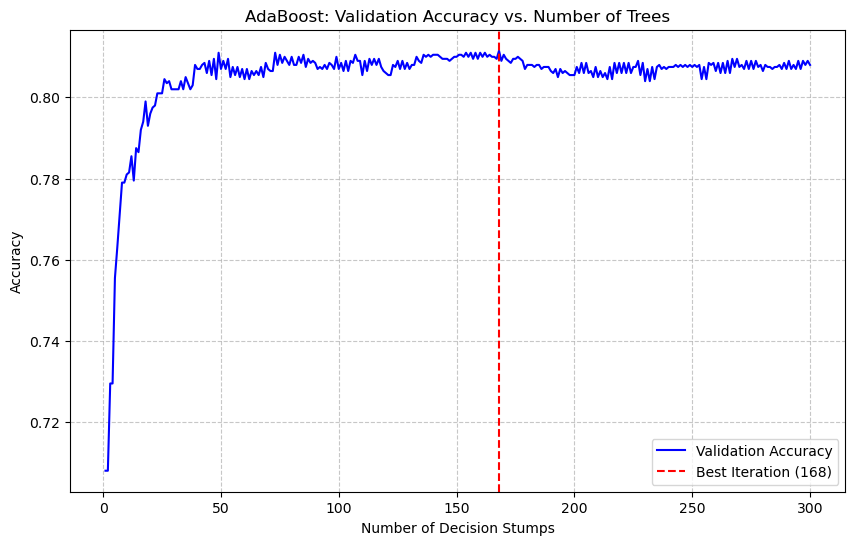


Final Test Accuracy (using 168 trees): 79.40733299849322%


In [10]:
num_trees = 300
ensemble = []
alphas = []
val_accuracies = []

N = x_train_reduced.shape[0]
weights = np.ones(N) / N
running_val_pred = np.zeros(x_val_reduced.shape[0])

for t in range(num_trees):
    print(f"\nTraining Tree #{t}")
    #tree t, weighted error and alpha
    stump, err_val = decision_stump(x_train_reduced, y_train, weights)
    a_t = alpha(err_val)

    #update weights for misclassified samples only, update by multiplying by exp(2 alpha)
    pred_train = predict(stump, x_train_reduced)
    weights = update_weights(weights, y_train, pred_train,a_t)
    
    #add stump to the ensemble
    ensemble.append(stump)
    alphas.append(a_t)
    
    #accuracy on val set
    running_val_pred += a_t * predict(stump, x_val_reduced)
    val_acc = np.mean(np.sign(running_val_pred) == y_val)
    val_accuracies.append(val_acc)
    #print(f"Accuracy: {val_acc*100}%, Alpha: {a_t}, Weighted Error: {err_val}")

best_iteration_idx = np.argmax(val_accuracies)
best_num_trees = best_iteration_idx + 1
best_val_acc = val_accuracies[best_iteration_idx]
print(f"Highest Validation Accuracy: {best_val_acc*100}% achieved at {best_num_trees} trees.")


plt.figure(figsize=(10, 6))
plt.plot(range(1, num_trees + 1), val_accuracies, label="Validation Accuracy", color='b')
plt.axvline(x=best_num_trees, color='r', linestyle='--', label=f"Best Iteration ({best_num_trees})")
plt.title("AdaBoost: Validation Accuracy vs. Number of Trees")
plt.xlabel("Number of Decision Stumps")
plt.ylabel("Accuracy")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

test_pred = predict_ensemble(ensemble, alphas, x_test_reduced, best_num_trees)
test_accuracy = np.mean(test_pred == y_test)

print(f"\nFinal Test Accuracy (using {best_num_trees} trees): {test_accuracy*100}%")